# MSIN0093 Business Strategy and Analytics 23/24

## Workbook 2 - !strategic
## Machine Learning Models

# Import Libraries

In [30]:
# Import libraries
import os
import numpy as np
import pandas as pd

# Load Data

In [31]:
# Location of data
root = '/project/'

# Dataset
datasetName = 'station_demo_data.csv'

file_path = root + datasetName
file_path

df = pd.read_csv(file_path)

# Correlation-Heatmap - Check for Multicollinearity

/tmp/ipykernel_134/2728056362.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


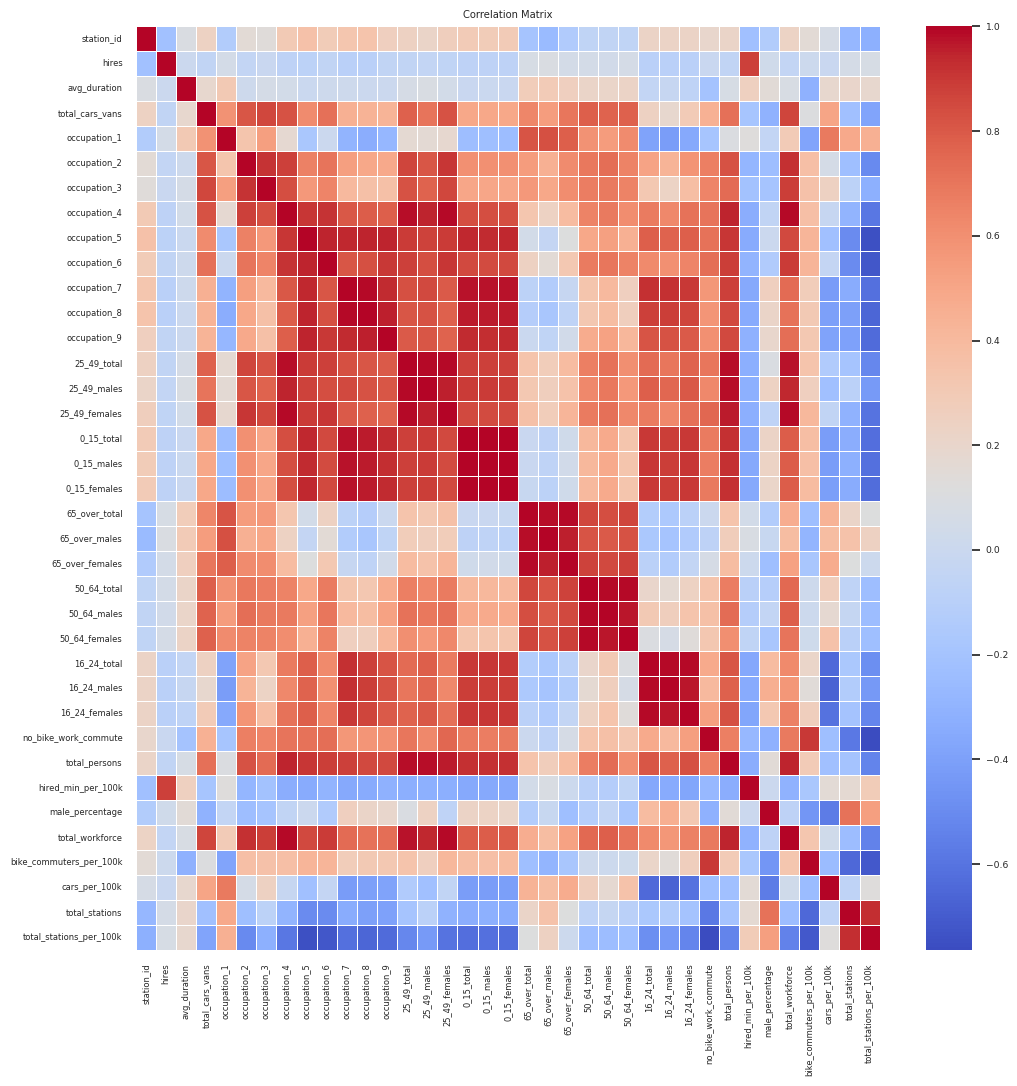

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
correlation_matrix = df.corr()
sns.set(font_scale=0.6)
# Create a heatmap for visualization
plt.figure(figsize=(12, 12))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title('Correlation Matrix')
plt.show()

# Feature Selection

In [33]:
age_predictors = ['0_15_total', '16_24_total', '25_49_total', '50_64_total', '65_over_total']

occupation_predictors = ['occupation_1', 'occupation_2', 'occupation_3', 'occupation_4', 'occupation_5',
                         'occupation_6', 'occupation_7', 'occupation_8', 'occupation_9']

feature_set =  age_predictors + occupation_predictors + ['male_percentage', 'bike_commuters_per_100k', 'cars_per_100k', 'total_stations_per_100k']
feature_set_wo_gender =  age_predictors + occupation_predictors + ['bike_commuters_per_100k', 'cars_per_100k', 'total_stations_per_100k']
feature_set_wo_gender_age = occupation_predictors + ['bike_commuters_per_100k', 'cars_per_100k', 'total_stations_per_100k']

# Run Model - OLS

In [34]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Target
y = df['hired_min_per_100k']

def run_ols_and_evaluate(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    ols_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
    y_pred_ols = ols_model.predict(sm.add_constant(X_test))
    mse_ols = mean_squared_error(y_test, y_pred_ols)
    r2_ols = r2_score(y_test, y_pred_ols)
    return ols_model.summary(), mse_ols, r2_ols

In [35]:
# Run OLS for all features
ols_summary, ols_all_features_mse, ols_all_features_r2 = run_ols_and_evaluate(df[feature_set], y)
print("OLS Regression Summary with all features:")
print(ols_summary)

OLS Regression Summary with all features:
                            OLS Regression Results                            
Dep. Variable:     hired_min_per_100k   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     12.35
Date:                Fri, 08 Dec 2023   Prob (F-statistic):           1.35e-19
Time:                        15:12:17   Log-Likelihood:                -5897.5
No. Observations:                 608   AIC:                         1.182e+04
Df Residuals:                     597   BIC:                         1.187e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

In [36]:
# Run OLS without gender
ols_summary, ols_wo_gender_mse, ols_wo_gender_r2 = run_ols_and_evaluate(df[feature_set_wo_gender], y)
print("\nOLS Regression Summary without gender:")
print(ols_summary)


OLS Regression Summary without gender:
                            OLS Regression Results                            
Dep. Variable:     hired_min_per_100k   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     12.35
Date:                Fri, 08 Dec 2023   Prob (F-statistic):           1.35e-19
Time:                        15:12:17   Log-Likelihood:                -5897.5
No. Observations:                 608   AIC:                         1.182e+04
Df Residuals:                     597   BIC:                         1.187e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [37]:
# Run OLS without gender and age
ols_summary, ols_wo_gender_age_mse, ols_wo_gender_age_r2 = run_ols_and_evaluate(df[feature_set_wo_gender_age], y)
print("\nOLS Regression Summary without gender and age:")
print(ols_summary)


OLS Regression Summary without gender:
                            OLS Regression Results                            
Dep. Variable:     hired_min_per_100k   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     12.35
Date:                Fri, 08 Dec 2023   Prob (F-statistic):           1.35e-19
Time:                        15:12:17   Log-Likelihood:                -5897.5
No. Observations:                 608   AIC:                         1.182e+04
Df Residuals:                     597   BIC:                         1.187e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

# Run Model - Random Forest

In [38]:
# Random Forest Regression without gender
X_rf = df[feature_set_wo_gender]

# Splitting the data into training and test sets
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y, test_size=0.2, random_state=0)

# Initialising and training
random_forest_model = RandomForestRegressor(random_state=0)
random_forest_model.fit(X_train_rf, y_train_rf)

# Making predictions and evaluating
y_pred_rf = random_forest_model.predict(X_test_rf)
mse_rf = mean_squared_error(y_test_rf, y_pred_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

rf_wo_gender_mse = mse_rf
rf_wo_gender_r2 = r2_rf 

# Result table

In [39]:
# Creating a summary DataFrame
summary_table = pd.DataFrame({
    "Model": ["OLS", "OLS", "OLS", "Random Forest"],
    "Feature Set": ["All Features", "Without Gender", "Without Gender & Age" , "Without Gender"],
    "MSE": [ols_all_features_mse, ols_wo_gender_mse, ols_wo_gender_age_mse, rf_wo_gender_mse],
    "R-squared": [ols_all_features_r2, ols_wo_gender_r2, ols_wo_gender_age_r2, rf_wo_gender_r2]
})
print(summary_table)

           Model           Feature Set           MSE  R-squared
0            OLS          All Features  1.031011e+07   0.126022
1            OLS        Without Gender  1.031011e+07   0.126022
2            OLS  Without Gender & Age  1.031011e+07   0.126022
3  Random Forest        Without Gender  1.029554e+07   0.127256
